# DATA PLOT ANALYSIS

In [32]:
import os
import argparse
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from cellpose.models import CellposeModel

from provided_code.metric import score
from provided_code.generate_submission import build_submission
from generate_train_submission import build_submission as one_submission

from my_paths import *

In [33]:
def get_stats(x):
    print(f"MEAN: {np.mean(x)}")
    print(f"MEDIAN: {np.median(x)}")
    print(f"MIN: {np.min(x)}")
    print(f"MAX: {np.max(x)}")

def load_dax(filepath, height=2048, width=2048):
    """Load a .dax raw image file. Raw uint16 binary, no header."""
    raw = np.fromfile(filepath, dtype=np.uint16)
    n_frames = len(raw) // (height * width)
    return raw.reshape(n_frames, height, width)

def normalize(x):
    return (x - x.min()) / (x.max() - x.min()) 

In [34]:
epi_stack = load_dax(TRAIN /  'FOV_001/Epi-750s5-635s5-545s1-473s5-408s5_001.dax')
print(f'Epi stack shape: {epi_stack.shape}  (frames, height, width)')
z_plane = 2  # middle z-plane
dapi = epi_stack[6 + z_plane * 5]   # frame 16 for z2
polyt = epi_stack[5 + z_plane * 5]  # frame 15 for z2

Epi stack shape: (27, 2048, 2048)  (frames, height, width)


In [35]:
# Model evaluation

# Cellpose v4+: use CellposeModel (not models.Cellpose)
model = CellposeModel(model_type='nuclei', gpu=True)

# TODO: USE THE POLYT IMAGE DATA
# eval() returns 3 values: masks, flows, styles
masks, flows, styles = model.eval(dapi, diameter=30, channels=[0, 0])

print(f'Segmentation complete!')
print(f'Mask shape: {masks.shape}')
print(f'Number of cells found: {masks.max()}')

model_type argument is not used in v4.0.1+. Ignoring this argument...
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


Segmentation complete!
Mask shape: (2048, 2048)
Number of cells found: 218


In [36]:
# Save masks to file
np.save(RESULTS / 'FOV_001_mask.npy', masks)

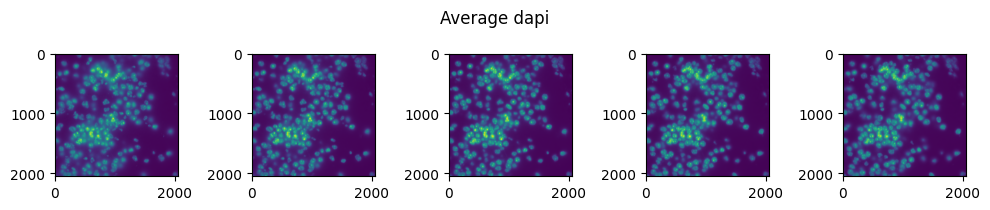

In [166]:
fig, ax = plt.subplots(1, 5)
fig.set_size_inches(10, 2)
for z in range(5):
    dapi = epi_stack[6 + z * 5]   # frame 16 for z2
    # ax[0, z].imshow(dapi)
    ax[z].imshow(dapi)
fig.suptitle('Average dapi')
plt.tight_layout()

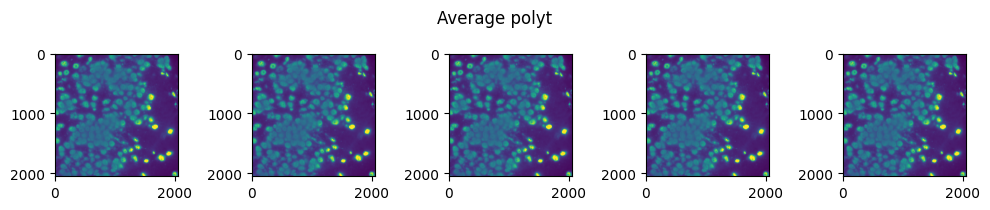

In [167]:
fig, ax = plt.subplots(1, 5)
fig.set_size_inches(10, 2)
for z in range(5):
    dapi = epi_stack[6 + z * 5]   # frame 16 for z2
    # ax[1, z].imshow(polyt)
    ax[z].imshow(polyt)
fig.suptitle('Average polyt')
plt.tight_layout()

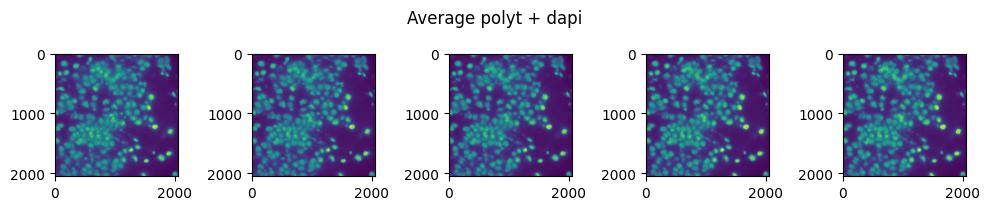

In [168]:
fig, ax = plt.subplots(1, 5)
fig.set_size_inches(10, 2)
for z in range(5):
    dapi = epi_stack[6 + z * 5]   # frame 16 for z2
    # ax[2, z].imshow(0.5 * normalize(polyt) + 0.5 * normalize(dapi))
    ax[z].imshow(0.5 * normalize(polyt) + 0.5 * normalize(dapi))
fig.suptitle('Average polyt + dapi')
plt.tight_layout()

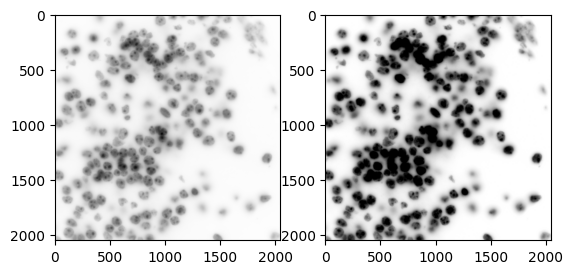

In [195]:
plt.subplot(1, 2, 1)
plt.imshow(dapi, cmap='grey_r')

plt.subplot(1, 2, 2)
vmin, vmax = np.percentile(dapi, [20, 95])
plt.imshow(np.clip(dapi, vmin, vmax), cmap='grey_r')

plt.show()

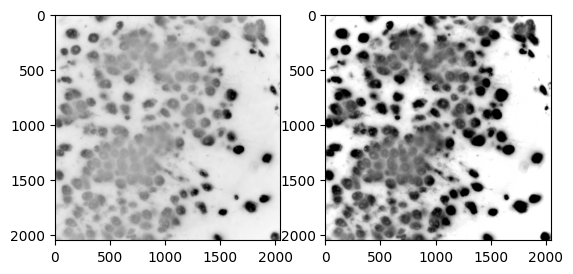

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(polyt, cmap='grey_r')

plt.subplot(1, 2, 2)
vmin, vmax = np.percentile(polyt, [20, 95])
plt.imshow(np.clip(polyt, vmin, vmax), cmap='grey_r')

plt.show()

In [40]:
# Basic Image Stats
# get_stats(polyt)
# get_stats(dapi)
# get_stats(normalize(polyt))
# get_stats(normalize(dapi))

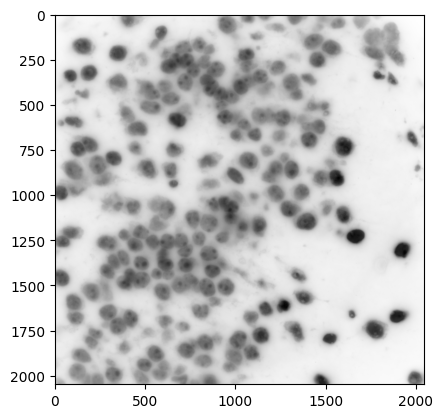

In [173]:
plt.imshow(0.5 * normalize(polyt) + 0.5 * normalize(dapi), cmap='grey_r')

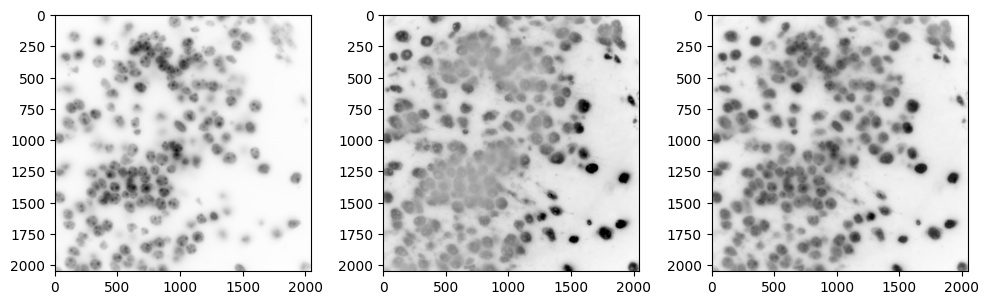

In [ ]:
plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(dapi, cmap='grey_r')
plt.subplot(1, 3, 2)
plt.imshow(polyt, cmap='grey_r')

plt.subplot(1, 3, 3)
plt.imshow(0.5 * normalize(polyt) + 0.5 * normalize(dapi), cmap='grey_r')

plt.tight_layout()
plt.show()

In [ ]:
# epi_stack = load_dax(TRAIN /  'FOV_001/Epi-750s5-635s5-545s1-473s5-408s5_001.dax')
# print(f'Epi stack shape: {epi_stack.shape}  (frames, height, width)')
# z_plane = 2  # middle z-plane
# dapi = epi_stack[6 + z_plane * 5]   # frame 16 for z2
# polyt = epi_stack[5 + z_plane * 5]  # frame 15 for z2

Epi stack shape: (27, 2048, 2048)  (frames, height, width)


In [43]:
# Model evaluation

# Cellpose v4+: use CellposeModel (not models.Cellpose)
model = CellposeModel(model_type='nuclei', gpu=True)

# TODO: USE THE POLYT IMAGE DATA
# eval() returns 3 values: masks, flows, styles
masks_dapi, flows_dapi, styles_dapi = model.eval(dapi, diameter=30, channels=[0, 0])
masks_polyt, flows_polyt, styles_polyt = model.eval(polyt, diameter=30, channels=[0, 0])

model_type argument is not used in v4.0.1+. Ignoring this argument...
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


In [ ]:
print(f'Segmentation complete!')
print(f'flows shape: {len(flows)}')
print(f'flows shape: {flows[0].shape}')
print(f'flows shape: {flows[1].shape}')
print(f'flows shape: {flows[2].shape}')
print(f'Mask shape: {masks.shape}')
print(f'Mask shape: {masks.shape}')
print(f'Number of cells found: {masks.max()}')
print(f'Unique Counts: {np.unique_counts(masks)}') 
# Compared against train solution, Unique Counts

Segmentation complete!
flows shape: 3
flows shape: (2048, 2048, 3)
flows shape: (2, 2048, 2048)
flows shape: (2048, 2048)
Mask shape: (2048, 2048)
Mask shape: (2048, 2048)
Number of cells found: 218
Unique Counts: UniqueCountsResult(values=array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136

In [45]:
# Random colormap for masks
from matplotlib.colors import ListedColormap
np.random.seed(42)
# colors = np.random.rand(masks.max() + 1, 4)
colors_dapi = np.zeros((masks.max() + 1, 4))
colors_dapi[:, 3] = 0.5  # alpha
colors_dapi[:, 2] = 1
colors_dapi[0] = [0, 0, 0, 0]  # background transparent
colors_dapi = ListedColormap(colors_dapi)

colors_polyt = np.zeros((masks.max() + 1, 4))
colors_polyt[:, 3] = 0.5  # alpha
colors_polyt[:, 1] = 1
colors_polyt[0] = [0, 0, 0, 0]  # background transparent
colors_polyt = ListedColormap(colors_polyt)

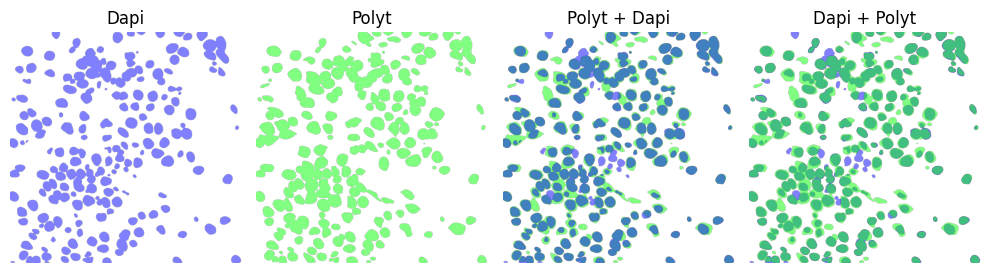

In [46]:
plt.figure(figsize=(10, 10))

plt.subplot(1, 4, 1)
plt.imshow(masks_dapi, cmap=colors_dapi)
plt.title('Dapi')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(masks_polyt, cmap=colors_polyt)
plt.axis('off')
plt.title('Polyt')

plt.subplot(1, 4, 3)
plt.imshow(masks_polyt, cmap=colors_polyt)
plt.imshow(masks_dapi, cmap=colors_dapi)
plt.axis('off')
plt.title('Polyt + Dapi')

plt.subplot(1, 4, 4)
plt.imshow(masks_dapi, cmap=colors_dapi)
plt.imshow(masks_polyt, cmap=colors_polyt)
plt.axis('off')
plt.title('Dapi + Polyt')

plt.tight_layout()
plt.show()

### Plotting Train Solution Attempt

In [176]:
# Load the spots train solution, with cell ids, only for FOV_001 and at z = 2
train_solution_df = pd.read_csv('results/spots_train_w_cell_id_solution.csv')
train_solution_df = train_solution_df[(train_solution_df['fov'] == "FOV_001") & (train_solution_df['global_z'] == 2.0)]
train_solution_df.head()

,Unnamed: 0,spot_id,fov,image_row,image_col,global_x,global_y,global_z,gt_cluster_id
1278119,1278119,1278119,FOV_001,1474,743,648.82880,2516.2058,2.0,233724746144689633921580435845750614925
1278120,1278120,1278120,FOV_001,809,385,721.27800,2477.2021,2.0,background
1278121,1278121,1278121,FOV_001,1399,463,656.97723,2485.6030,2.0,64136241853584675064530111120305936073
1278122,1278122,1278122,FOV_001,393,581,766.66130,2498.5620,2.0,52326809857185237633431938284131118490
1278123,1278123,1278123,FOV_001,280,629,778.95166,2503.7437,2.0,254195899676479487269941189987887216650


In [144]:
# THIS MEANS NOT EACH PIXEL IS CLASSIFIED, (background is included)
train_solution_df['image_row'].unique(), train_solution_df['image_col'].unique()

(array([1474,  809, 1399, ...,  413,  998, 1913], shape=(1845,)),
 array([ 743,  385,  463, ..., 1837, 1813, 1862], shape=(1843,)))

In [177]:
# Get cell boundries and convert from a string to a list

def parse_float_list(text):
    if isinstance(text, str):
        return np.fromstring(text, sep=',').tolist()
    return None

cell_boundaries_train_df = pd.read_csv(provided_code / 'cell_boundaries_train.csv')
cell_boundaries_train_df.iloc[:, 1:] = cell_boundaries_train_df.iloc[:, 1:].applymap(parse_float_list)

cell_boundaries_train_df.rename({'Unnamed: 0':'gt_cluster_id'}, inplace=True, axis=1)
cell_boundaries_train_df.head()

,gt_cluster_id,boundaryX_z0,boundaryY_z0,boundaryX_z1,boundaryY_z1,boundaryX_z2,boundaryY_z2,boundaryX_z3,boundaryY_z3,boundaryX_z4,boundaryY_z4
0,267725525651232306728125526231708191,"[-1343.5731309860944, -1343.5731309860944, -13...","[-474.1219997406006, -474.230999737978, -474.3...","[-1343.5731309860944, -1343.5731309860944, -13...","[-473.9039997458458, -474.0129997432232, -474....","[-1343.6821309834718, -1343.6821309834718, -13...","[-473.03199976682663, -473.140999764204, -473....","[-1343.7911309808492, -1343.7911309808492, -13...","[-474.0129997432232, -474.1219997406006, -474....","[-1343.7911309808492, -1343.7911309808492, -13...","[-473.140999764204, -473.2499997615814, -473.3..."
1,327375991457903881984615241423065475,"[2189.4068658143283, 2189.4068658143283, 2189....","[-1787.903062850237, -1788.0120628476143, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1789.2110628187656, -1789.320062816143, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.6660628318787, -1788.775062829256, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.775062829256, -1788.8840628266335, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1788.4480628371239, -1788.5570628345013, -17..."
2,364755379140285267217928676041057312,"[-1336.3791311591863, -1336.3791311591863, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1336.7061311513185, -1336.7061311513185, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1334.5261312037705, -1334.5261312037705, -13...","[-531.6739983558655, -531.7829983532429, -531....","[-1333.3271312326192, -1333.338031232357, -133...","[-531.5649983584881, -531.5758983582258, -531....","[-1333.2181312352418, -1333.2181312352418, -13...","[-531.1289983689785, -531.2379983663559, -531...."
3,377956362916104527021675785082246047,"[174.90989572703836, 174.90989572703836, 174.9...","[2337.431938946247, 2337.3229389488697, 2337.2...","[174.58289573490617, 174.58289573490617, 174.5...","[2338.6309389173985, 2338.521938920021, 2338.4...","[174.255895742774, 174.255895742774, 174.25589...","[2338.3039389252663, 2338.194938927889, 2338.0...","[173.8198957532644, 173.8198957532644, 173.819...","[2337.3229389488697, 2337.2139389514923, 2337....","[173.8198957532644, 173.8198957532644, 173.819...","[2337.431938946247, 2337.3229389488697, 2337.2..."
4,429470755737170534203514668497237885,"[-1013.4271341174841, -1013.4271341174841, -10...","[-573.951002150774, -574.0600021481514, -574.1...","[-1012.010134151578, -1012.010134151578, -1012...","[-572.9700021743774, -573.0790021717548, -573....","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.0790021717548, -573.1880021691322, -573....","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.2970021665096, -573.406002163887, -573.5...","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.8420021533966, -573.951002150774, -574.0..."


In [178]:
# Only get cell boundries found in FOV_001 and z = 2
solution_cells_df = cell_boundaries_train_df.merge(train_solution_df, how='inner', on='gt_cluster_id')
solution_cells_df = solution_cells_df[['gt_cluster_id', 'boundaryX_z2','boundaryY_z2' , 'image_row','image_col', 'fov', 'spot_id']]
solution_cells_df.head()

,gt_cluster_id,boundaryX_z2,boundaryY_z2,image_row,image_col,fov,spot_id
0,3144419438333404217801286104134093595,"[620.6748698741197, 620.6748698741197, 620.674...","[2559.994938403368, 2559.8859384059906, 2559.7...",1751,1101,FOV_001,1278259
1,3144419438333404217801286104134093595,"[620.6748698741197, 620.6748698741197, 620.674...","[2559.994938403368, 2559.8859384059906, 2559.7...",1807,1150,FOV_001,1278368
2,3144419438333404217801286104134093595,"[620.6748698741197, 620.6748698741197, 620.674...","[2559.994938403368, 2559.8859384059906, 2559.7...",1818,1153,FOV_001,1279053
3,3144419438333404217801286104134093595,"[620.6748698741197, 620.6748698741197, 620.674...","[2559.994938403368, 2559.8859384059906, 2559.7...",1778,1184,FOV_001,1279080
4,3144419438333404217801286104134093595,"[620.6748698741197, 620.6748698741197, 620.674...","[2559.994938403368, 2559.8859384059906, 2559.7...",1805,1179,FOV_001,1280871


In [179]:
# Consolidate so each cell gets one row and 1 boundry
def agg_func(df):
    # print(type(test))
    # print(test)
    df = df.sort_values(['image_row', 'image_col'])
    x_b = df['boundaryX_z2'].iloc[0]
    y_b = df['boundaryY_z2'].iloc[0]
    row_n = df['image_row']
    col_n = df['image_col']
    img_points = list(zip(row_n, col_n))
    boundry = list(zip(x_b, y_b))
    return pd.Series({
        'boundaryX_z2' : x_b,
        'boundaryY_z2' : y_b,
        'image_row' : row_n,
        'image_col' : col_n,
        'img_points' : img_points,
    })

apply_solution_cells_df = solution_cells_df.groupby('gt_cluster_id').apply(agg_func)
apply_solution_cells_df = apply_solution_cells_df.reset_index()
# apply_solution_cells_df, apply_solution_cells_df.index
apply_solution_cells_df.head()

,gt_cluster_id,boundaryX_z2,boundaryY_z2,image_row,image_col,img_points
0,101439145736043450739518792393319275728,"[785.9188658982515, 785.9079658985138, 785.809...","[2516.503939449787, 2516.4930394500493, 2516.3...",2044 216 2040 216 2034 219 2069 21...,2044 728 2040 734 2034 722 2069 73...,"[(216, 728), (216, 734), (219, 722), (219, 732..."
1,107339403196096197173988667637043198581,"[609.342995852232, 609.2339958548546, 609.1358...","[2553.553038558364, 2553.553038558364, 2553.45...",2099 1830 2081 1834 2079 1836 2087 ...,2099 1137 2081 1128 2079 1127 2087 ...,"[(1830, 1137), (1834, 1128), (1836, 1127), (18..."
2,110560886183203995207186932129509147628,"[797.6908656150102, 797.6908656150102, 797.690...","[2593.4579375982285, 2593.348937600851, 2593.2...",2119 107 2176 107 2117 110 2123 11...,2119 1435 2176 1455 2117 1449 2123 ...,"[(107, 1435), (107, 1455), (110, 1449), (111, ..."
3,112601199177566910056614324862459689659,"[649.7778691738844, 649.7778691738844, 649.777...","[2527.2949391901493, 2527.185939192772, 2527.0...",2191 1463 2248 1464 2241 1464 2183 ...,2191 833 2248 829 2241 842 2183 85...,"[(1463, 833), (1464, 829), (1464, 842), (1465,..."
4,120201812905061612354923296176499861022,"[675.8288685470819, 675.8288685470819, 675.828...","[2467.126940637827, 2467.0179406404495, 2466.9...",2332 1226 2305 1227 2306 1227 2282 ...,2332 291 2305 267 2306 282 2282 30...,"[(1226, 291), (1227, 267), (1227, 282), (1227,..."


There are 133 cells detected


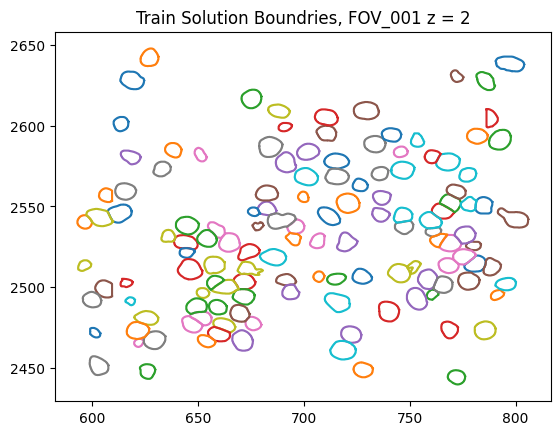

In [159]:
for i in range(len(apply_solution_cells_df)):
    plt.plot(apply_solution_cells_df.loc[i, 'boundaryX_z2'], apply_solution_cells_df.loc[i, 'boundaryY_z2'])

print(f"There are {len(apply_solution_cells_df)} cells detected")

plt.title('Train Solution Boundries, FOV_001 z = 2')
# plt.axis('off')
plt.show()

NOTE: Not sure the orientation is the same or correct, how to compare to the dapi and polyt images

Conclusion: The train solution has considerably less cell detections (133) than the cellpose (218). 

216 728 1
216 734 1
219 722 1
219 732 1
220 742 1
221 747 1
221 752 1
222 714 1
223 728 1
228 709 1
228 719 1
229 768 1
232 766 1
233 709 1
233 761 1
235 703 1
235 749 1
236 711 1
238 697 1
238 749 1
239 730 1
242 776 1
243 721 1
245 774 1
246 774 1
248 752 1
251 746 1
252 726 1
253 776 1
256 691 1
256 766 1
258 730 1
266 690 1
278 687 1
282 716 1
285 697 1
286 727 1
287 697 1
290 727 1
293 717 1
298 717 1
303 728 1
304 716 1
1830 1137 2
1834 1128 2
1836 1127 2
1843 1110 2
1850 1084 2
1851 1109 2
1853 1155 2
1856 1104 2
1856 1109 2
1858 1148 2
1860 1157 2
1861 1136 2
1863 1154 2
1864 1115 2
1866 1108 2
1867 1143 2
1871 1119 2
1874 1107 2
1875 1136 2
1876 1111 2
1878 1114 2
1878 1117 2
1878 1130 2
1879 1133 2
1884 1126 2
107 1435 3
107 1455 3
110 1449 3
111 1461 3
112 1434 3
113 1430 3
113 1439 3
113 1442 3
114 1425 3
115 1473 3
118 1452 3
118 1471 3
123 1418 3
124 1409 3
124 1422 3
125 1412 3
127 1416 3
129 1400 3
129 1466 3
130 1411 3
137 1407 3
140 1482 3
140 1487 3
143 1448 3
148 14

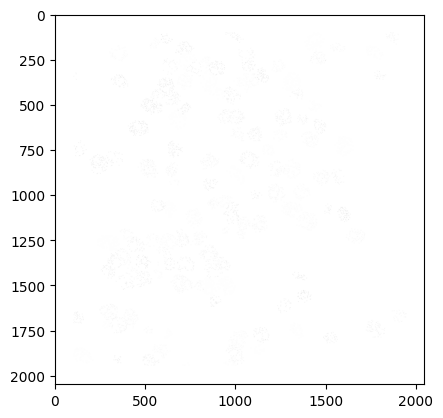

In [158]:
# This attempt is to generate a MASK fromt he training solution, however,
# there seems to many missing "spots" or row and col pixel values

mask_solution = np.zeros((2048, 2048))
# mask_solution[0:100, 0:100] = 1
def to_mask(index, image_points:list):
    for x, y in image_points:
        print(x, y, index + 1)
        mask_solution[x, y] = index + 1
        # mask_solution[x, y] = 1
        # mask_solution[x, y] = 1

# apply_solution_cells_df
for idx in range(len(apply_solution_cells_df)):
    point_list = apply_solution_cells_df.loc[idx, 'img_points']
    # print(point_list)
    to_mask(idx, point_list)

print(np.unique_counts(mask_solution))
# print(np.unique_values(mask_solution))
print(mask_solution.shape)
plt.imshow(mask_solution, cmap='grey_r')
plt.show()

## Load Spots Train CSV

In [11]:
spots_train_df = pd.read_csv(provided_code / 'spots_train.csv')
# Check to see the range of values
spots_train_df['global_x'].max(), spots_train_df['global_x'].min(), spots_train_df['global_x'].median(), spots_train_df['global_y'].max(), spots_train_df['global_y'].min(), spots_train_df['global_y'].median()

(np.float64(5798.334),
 np.float64(-2402.6602),
 np.float64(675.7866),
 np.float64(2647.3037),
 np.float64(-1953.6913),
 np.float64(746.13824))

In [12]:
spots_train_df.columns

Index(['barcode_id', 'fov', 'image_row', 'image_col', 'global_x', 'global_y',
       'global_z', 'x', 'y', 'target_gene'],
      dtype='object')

In [13]:
# spots_train_df = spots_train_df[spots_train_df['fov'] == 'FOV_001']
spots_train_df = spots_train_df[['fov', 'image_row', 'image_col', 'global_x', 'global_y', 'global_z']]
spots_train_df.head(4)

,fov,image_row,image_col,global_x,global_y,global_z
0,FOV_019,1468,1575,5649.4106,-393.08737,0.0
1,FOV_019,303,1800,5776.4834,-368.60250,0.0
2,FOV_019,749,579,5727.8633,-501.73105,0.0
3,FOV_019,1100,704,5689.5854,-488.09860,0.0


In [14]:
spots_train_df['fov'].value_counts()

fov
FOV_001    117893
FOV_025     96648
FOV_011     94166
FOV_020     93692
FOV_035     91610
FOV_017     88478
FOV_031     87881
FOV_006     83153
FOV_002     80581
FOV_012     78605
FOV_034     77318
FOV_022     77214
FOV_033     76323
FOV_003     73217
FOV_019     72619
FOV_004     71555
FOV_038     70272
FOV_007     68477
FOV_014     67028
FOV_009     63693
FOV_030     63345
FOV_039     62342
FOV_010     61579
FOV_040     60352
FOV_008     60136
FOV_021     56208
FOV_037     56089
FOV_032     55973
FOV_029     54886
FOV_013     54197
FOV_016     53516
FOV_018     52501
FOV_028     52472
FOV_015     52204
FOV_027     50633
FOV_036     50077
FOV_005     40010
FOV_024     32671
FOV_026     30165
FOV_023     29580
Name: count, dtype: int64

In [15]:
import torch
import gc
# 1. Delete large objects
# del model 
# 2. Force garbage collection
gc.collect()
# 3. Clear the PyTorch cache
torch.cuda.empty_cache()

## Load Test Set

In [16]:
# We need to recreate the spot_id column
test_spots_df = pd.read_csv(provided_code / 'test_spots.csv')
test_spots_df.columns

Index(['spot_id', 'fov', 'image_row', 'image_col', 'global_x', 'global_y',
       'global_z', 'target_gene'],
      dtype='object')

In [17]:
test_spots_df = test_spots_df[['spot_id', 'fov', 'image_row', 'image_col', 'global_x', 'global_y', 'global_z']]
test_spots_df.head(5)

,spot_id,fov,image_row,image_col,global_x,global_y,global_z
0,spot_0,FOV_B,1899,511,-1797.5458,90.93547,0.0
1,spot_1,FOV_B,812,140,-1679.0660,50.45134,0.0
2,spot_2,FOV_B,1913,190,-1799.0302,55.88918,0.0
3,spot_3,FOV_B,1275,734,-1729.5323,115.19051,0.0
4,spot_4,FOV_B,1297,765,-1731.9692,118.57968,0.0


## CALCULATE SCORE FROM 
- cell_boundaries_train.csv
- spots_train.csv


In [18]:
from tqdm import tqdm
from shapely.geometry import Point, Polygon

poly = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])
point = Point(0.5, 0.5)
print(poly.contains(point))  # Output: True

True


In [19]:
# Get cell boundries and convert from a string to a list

def parse_float_list(text):
    if isinstance(text, str):
        return np.fromstring(text, sep=',').tolist()
    return None

cell_boundaries_train_df = pd.read_csv(provided_code / 'cell_boundaries_train.csv')
cell_boundaries_train_df.iloc[:, 1:] = cell_boundaries_train_df.iloc[:, 1:].applymap(parse_float_list)

In [20]:
cell_boundaries_train_df.head(4)

,Unnamed: 0,boundaryX_z0,boundaryY_z0,boundaryX_z1,boundaryY_z1,boundaryX_z2,boundaryY_z2,boundaryX_z3,boundaryY_z3,boundaryX_z4,boundaryY_z4
0,267725525651232306728125526231708191,"[-1343.5731309860944, -1343.5731309860944, -13...","[-474.1219997406006, -474.230999737978, -474.3...","[-1343.5731309860944, -1343.5731309860944, -13...","[-473.9039997458458, -474.0129997432232, -474....","[-1343.6821309834718, -1343.6821309834718, -13...","[-473.03199976682663, -473.140999764204, -473....","[-1343.7911309808492, -1343.7911309808492, -13...","[-474.0129997432232, -474.1219997406006, -474....","[-1343.7911309808492, -1343.7911309808492, -13...","[-473.140999764204, -473.2499997615814, -473.3..."
1,327375991457903881984615241423065475,"[2189.4068658143283, 2189.4068658143283, 2189....","[-1787.903062850237, -1788.0120628476143, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1789.2110628187656, -1789.320062816143, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.6660628318787, -1788.775062829256, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.775062829256, -1788.8840628266335, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1788.4480628371239, -1788.5570628345013, -17..."
2,364755379140285267217928676041057312,"[-1336.3791311591863, -1336.3791311591863, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1336.7061311513185, -1336.7061311513185, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1334.5261312037705, -1334.5261312037705, -13...","[-531.6739983558655, -531.7829983532429, -531....","[-1333.3271312326192, -1333.338031232357, -133...","[-531.5649983584881, -531.5758983582258, -531....","[-1333.2181312352418, -1333.2181312352418, -13...","[-531.1289983689785, -531.2379983663559, -531...."
3,377956362916104527021675785082246047,"[174.90989572703836, 174.90989572703836, 174.9...","[2337.431938946247, 2337.3229389488697, 2337.2...","[174.58289573490617, 174.58289573490617, 174.5...","[2338.6309389173985, 2338.521938920021, 2338.4...","[174.255895742774, 174.255895742774, 174.25589...","[2338.3039389252663, 2338.194938927889, 2338.0...","[173.8198957532644, 173.8198957532644, 173.819...","[2337.3229389488697, 2337.2139389514923, 2337....","[173.8198957532644, 173.8198957532644, 173.819...","[2337.431938946247, 2337.3229389488697, 2337.2..."


In [21]:
# Get basic view
def get_first(x):
    if x:
        return x[0]
    return None
x_boundry_test = cell_boundaries_train_df['boundaryX_z2'].transform(get_first)
cell_boundaries_train_df.shape, x_boundry_test.min(), x_boundry_test.max(), x_boundry_test.median()


((4082, 11),
 np.float64(-2413.780029296875),
 np.float64(5809.343209475279),
 np.float64(1058.5523689627648))

In [22]:
# This shows that some cells do not span across entire z-plane.
# cell_boundaries_train_df[cell_boundaries_train_df.iloc[:, 1:].isna().sum(axis=1) > 0]
# cell_boundaries_train_df[cell_boundaries_train_df.iloc[:, 1:].isna().sum(axis=1) == 8]

# All cells listed have at least 1 z plane
cell_boundaries_train_df[cell_boundaries_train_df.iloc[:, 1:].isna().sum(axis=1) == 10]

# All Cell IDs exist
# cell_boundaries_train_df['Unnamed: 0'].isna().sum()

,Unnamed: 0,boundaryX_z0,boundaryY_z0,boundaryX_z1,boundaryY_z1,boundaryX_z2,boundaryY_z2,boundaryX_z3,boundaryY_z3,boundaryX_z4,boundaryY_z4


### Load / Show All Relevant DF

In [23]:
test_spots_df.head()

,spot_id,fov,image_row,image_col,global_x,global_y,global_z
0,spot_0,FOV_B,1899,511,-1797.5458,90.93547,0.0
1,spot_1,FOV_B,812,140,-1679.0660,50.45134,0.0
2,spot_2,FOV_B,1913,190,-1799.0302,55.88918,0.0
3,spot_3,FOV_B,1275,734,-1729.5323,115.19051,0.0
4,spot_4,FOV_B,1297,765,-1731.9692,118.57968,0.0


In [24]:
# TODO: For each FOV, for each Z, Mask -> split into individiual pixels
spots_train_df.head()

,fov,image_row,image_col,global_x,global_y,global_z
0,FOV_019,1468,1575,5649.4106,-393.08737,0.0
1,FOV_019,303,1800,5776.4834,-368.60250,0.0
2,FOV_019,749,579,5727.8633,-501.73105,0.0
3,FOV_019,1100,704,5689.5854,-488.09860,0.0
4,FOV_019,522,118,5752.5440,-551.92944,0.0


In [25]:
cell_boundaries_train_df.head()

,Unnamed: 0,boundaryX_z0,boundaryY_z0,boundaryX_z1,boundaryY_z1,boundaryX_z2,boundaryY_z2,boundaryX_z3,boundaryY_z3,boundaryX_z4,boundaryY_z4
0,267725525651232306728125526231708191,"[-1343.5731309860944, -1343.5731309860944, -13...","[-474.1219997406006, -474.230999737978, -474.3...","[-1343.5731309860944, -1343.5731309860944, -13...","[-473.9039997458458, -474.0129997432232, -474....","[-1343.6821309834718, -1343.6821309834718, -13...","[-473.03199976682663, -473.140999764204, -473....","[-1343.7911309808492, -1343.7911309808492, -13...","[-474.0129997432232, -474.1219997406006, -474....","[-1343.7911309808492, -1343.7911309808492, -13...","[-473.140999764204, -473.2499997615814, -473.3..."
1,327375991457903881984615241423065475,"[2189.4068658143283, 2189.4068658143283, 2189....","[-1787.903062850237, -1788.0120628476143, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1789.2110628187656, -1789.320062816143, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.6660628318787, -1788.775062829256, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.775062829256, -1788.8840628266335, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1788.4480628371239, -1788.5570628345013, -17..."
2,364755379140285267217928676041057312,"[-1336.3791311591863, -1336.3791311591863, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1336.7061311513185, -1336.7061311513185, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1334.5261312037705, -1334.5261312037705, -13...","[-531.6739983558655, -531.7829983532429, -531....","[-1333.3271312326192, -1333.338031232357, -133...","[-531.5649983584881, -531.5758983582258, -531....","[-1333.2181312352418, -1333.2181312352418, -13...","[-531.1289983689785, -531.2379983663559, -531...."
3,377956362916104527021675785082246047,"[174.90989572703836, 174.90989572703836, 174.9...","[2337.431938946247, 2337.3229389488697, 2337.2...","[174.58289573490617, 174.58289573490617, 174.5...","[2338.6309389173985, 2338.521938920021, 2338.4...","[174.255895742774, 174.255895742774, 174.25589...","[2338.3039389252663, 2338.194938927889, 2338.0...","[173.8198957532644, 173.8198957532644, 173.819...","[2337.3229389488697, 2337.2139389514923, 2337....","[173.8198957532644, 173.8198957532644, 173.819...","[2337.431938946247, 2337.3229389488697, 2337.2..."
4,429470755737170534203514668497237885,"[-1013.4271341174841, -1013.4271341174841, -10...","[-573.951002150774, -574.0600021481514, -574.1...","[-1012.010134151578, -1012.010134151578, -1012...","[-572.9700021743774, -573.0790021717548, -573....","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.0790021717548, -573.1880021691322, -573....","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.2970021665096, -573.406002163887, -573.5...","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.8420021533966, -573.951002150774, -574.0..."


### Polygon Pre-Processing Helper

In [26]:
# Converts the x and y columns in the cell boundries df and converts them to polygons so point detection

def get_polygon_df(df:pd.DataFrame):
    out_df = df[['Unnamed: 0']]
    for z in range(5):
        z_polygons = []
        for r in range(df.shape[0]):
            if df.iloc[r, 1 + z * 2]:
                # If there is a boundry detected on a z axis
                x_points = df.iloc[r, 1 + z * 2]
                y_points = df.iloc[r, 2 + z * 2]
                points = list(zip(x_points, y_points))
                z_polygons.append(Polygon(points))
            else:
                # If there is a NO boundry detected on a z axis, no polygon
                z_polygons.append(None)

        out_df[f"polygon_z{z}"] = pd.Series(z_polygons)

    return out_df

polygon_df = get_polygon_df(cell_boundaries_train_df)
polygon_df.shape, polygon_df.columns

((4082, 6),
 Index(['Unnamed: 0', 'polygon_z0', 'polygon_z1', 'polygon_z2', 'polygon_z3',
        'polygon_z4'],
       dtype='object'))

In [27]:
polygon_df.head()

,Unnamed: 0,polygon_z0,polygon_z1,polygon_z2,polygon_z3,polygon_z4
0,267725525651232306728125526231708191,POLYGON ((-1343.5731309860944 -474.12199974060...,POLYGON ((-1343.5731309860944 -473.90399974584...,POLYGON ((-1343.6821309834718 -473.03199976682...,POLYGON ((-1343.7911309808492 -474.01299974322...,POLYGON ((-1343.7911309808492 -473.14099976420...
1,327375991457903881984615241423065475,POLYGON ((2189.4068658143283 -1787.90306285023...,POLYGON ((2189.624865809083 -1789.211062818765...,POLYGON ((2189.4068658143283 -1788.66606283187...,POLYGON ((2189.4068658143283 -1788.77506282925...,POLYGON ((2189.624865809083 -1788.448062837123...
2,364755379140285267217928676041057312,POLYGON ((-1336.3791311591863 -533.74499830603...,POLYGON ((-1336.7061311513185 -533.74499830603...,POLYGON ((-1334.5261312037705 -531.67399835586...,POLYGON ((-1333.3271312326192 -531.56499835848...,POLYGON ((-1333.2181312352418 -531.12899836897...
3,377956362916104527021675785082246047,POLYGON ((174.90989572703836 2337.431938946247...,POLYGON ((174.58289573490617 2338.630938917398...,"POLYGON ((174.255895742774 2338.3039389252663,...",POLYGON ((173.8198957532644 2337.3229389488697...,"POLYGON ((173.8198957532644 2337.431938946247,..."
4,429470755737170534203514668497237885,POLYGON ((-1013.4271341174841 -573.95100215077...,POLYGON ((-1012.010134151578 -572.970002174377...,POLYGON ((-1012.7731341332197 -573.07900217175...,POLYGON ((-1012.7731341332197 -573.29700216650...,POLYGON ((-1012.7731341332197 -573.84200215339...


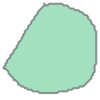

In [28]:
# Visualization
# z = 0
# x_points = cell_boundaries_train_df.iloc[0, 1 + z * 2]
# y_points = cell_boundaries_train_df.iloc[0, 2 + z * 2]
# plt.plot(x_points, y_points) # Cool!
# plt.show()

# Visualization
# points_z0 = list(zip(cell_boundaries_train_df.iloc[0, 1], cell_boundaries_train_df.iloc[0, 2]))
# Polygon(points_z0)

# Visualization
polygon_df['polygon_z0'][300]

In [29]:
polygon_df.head()

,Unnamed: 0,polygon_z0,polygon_z1,polygon_z2,polygon_z3,polygon_z4
0,267725525651232306728125526231708191,POLYGON ((-1343.5731309860944 -474.12199974060...,POLYGON ((-1343.5731309860944 -473.90399974584...,POLYGON ((-1343.6821309834718 -473.03199976682...,POLYGON ((-1343.7911309808492 -474.01299974322...,POLYGON ((-1343.7911309808492 -473.14099976420...
1,327375991457903881984615241423065475,POLYGON ((2189.4068658143283 -1787.90306285023...,POLYGON ((2189.624865809083 -1789.211062818765...,POLYGON ((2189.4068658143283 -1788.66606283187...,POLYGON ((2189.4068658143283 -1788.77506282925...,POLYGON ((2189.624865809083 -1788.448062837123...
2,364755379140285267217928676041057312,POLYGON ((-1336.3791311591863 -533.74499830603...,POLYGON ((-1336.7061311513185 -533.74499830603...,POLYGON ((-1334.5261312037705 -531.67399835586...,POLYGON ((-1333.3271312326192 -531.56499835848...,POLYGON ((-1333.2181312352418 -531.12899836897...
3,377956362916104527021675785082246047,POLYGON ((174.90989572703836 2337.431938946247...,POLYGON ((174.58289573490617 2338.630938917398...,"POLYGON ((174.255895742774 2338.3039389252663,...",POLYGON ((173.8198957532644 2337.3229389488697...,"POLYGON ((173.8198957532644 2337.431938946247,..."
4,429470755737170534203514668497237885,POLYGON ((-1013.4271341174841 -573.95100215077...,POLYGON ((-1012.010134151578 -572.970002174377...,POLYGON ((-1012.7731341332197 -573.07900217175...,POLYGON ((-1012.7731341332197 -573.29700216650...,POLYGON ((-1012.7731341332197 -573.84200215339...


### Submission

In [30]:
# NOTE: Original version, DEPRICATED

# WE ITERATE ACROSS ALL SPOTS DETECTED (MASK) FIRST 
# submission_df = []
# for s in tqdm(range(spots_train_df.shape[0])):
#     spot_row = spots_train_df.iloc[s, :]
#     global_x = int(spot_row['global_x'])
#     global_y = int(spot_row['global_y'])
#     global_z = int(spot_row['global_z'])

#     submission_row = {
#         'spot_id' : s,
#         'fov' : spot_row['fov'],
#         'gt_cluster_id' : 'background'
#     }

#     for cell in tqdm(range(polygon_df.shape[0]), leave=False, disable=True):
#         cell_row = polygon_df.loc[cell, :]

#             # if there is an NA, then the cell is not on this z-plane, skip
#         if not cell_row[f"polygon_z{global_z}"]:
#             continue

#         if (cell_row[f"polygon_z{global_z}"].contains(Point((global_x, global_y) ))):
#             submission_row['gt_cluster_id'] = cell_row["Unnamed: 0"]
#             break

#     submission_df.append(submission_row)

# submission_df = pd.DataFrame(submission_df)
# submission_df

In [31]:
# Claude Optimization
# https://claude.ai/share/db1c3b53-241d-4d0e-9222-abd4566a4d89
from shapely.strtree import STRtree
from shapely.geometry import Point
from tqdm import tqdm
import pandas as pd
import numpy as np

def assign_spots_to_cells(spots_train_df, polygon_df):
    rows = []
    
    # Pre-compute unique z-planes to avoid repeated string formatting
    # z_planes = spots_train_df['global_z'].unique()
    # print("z_planes", z_planes)
    # return
    
    # Pre-build spatial index per z-plane: {z: (STRtree, list of cell ids)}
    spatial_index = {}
    # for z in z_planes:
    for z in range(0, 5):
        col = f"polygon_z{z}"
        # if col not in polygon_df.columns:
        #     continue
        
        # Only keep rows where polygon is not null/falsy for this z
        valid = polygon_df[polygon_df[col].notna() & polygon_df[col].astype(bool)]
        if valid.empty:
            continue
        
        polygons = valid[col].tolist()
        cell_ids = valid["Unnamed: 0"].tolist()
        tree = STRtree(polygons)
        spatial_index[z] = (tree, polygons, cell_ids)
    
    # Main loop — now O(n log m) instead of O(n*m)
    for s, spot_row in enumerate(tqdm(spots_train_df.itertuples(), total=len(spots_train_df))):
        global_x = int(spot_row.global_x)
        global_y = int(spot_row.global_y)
        global_z = int(spot_row.global_z)
        
        gt_cluster_id = 'background'
        
        if global_z in spatial_index:
            tree, polygons, cell_ids = spatial_index[global_z]
            point = Point(global_x, global_y)
            
            # Query returns indices of candidate polygons (bounding box hit)
            candidates = tree.query(point)
            for idx in candidates:
                if polygons[idx].contains(point):
                    gt_cluster_id = cell_ids[idx]
                    break
        
        rows.append({
            'spot_id': s,
            'fov': spot_row.fov,
            'image_row': spot_row.image_row,
            'image_col': spot_row.image_col,
            'global_x': spot_row.global_x,
            'global_y': spot_row.global_y,
            'global_z': spot_row.global_z,
            'gt_cluster_id': gt_cluster_id,
        })
    
    return pd.DataFrame(rows)

train_solution_df = assign_spots_to_cells(spots_train_df, polygon_df)

  0%|          | 0/2659359 [00:00<?, ?it/s]

100%|██████████| 2659359/2659359 [00:22<00:00, 118140.50it/s]


In [32]:
train_solution_df.head()

,spot_id,fov,image_row,image_col,global_x,global_y,global_z,gt_cluster_id
0,0,FOV_019,1468,1575,5649.4106,-393.08737,0.0,background
1,1,FOV_019,303,1800,5776.4834,-368.60250,0.0,background
2,2,FOV_019,749,579,5727.8633,-501.73105,0.0,background
3,3,FOV_019,1100,704,5689.5854,-488.09860,0.0,background
4,4,FOV_019,522,118,5752.5440,-551.92944,0.0,background


In [33]:
spots_train_df.head()

,fov,image_row,image_col,global_x,global_y,global_z
0,FOV_019,1468,1575,5649.4106,-393.08737,0.0
1,FOV_019,303,1800,5776.4834,-368.60250,0.0
2,FOV_019,749,579,5727.8633,-501.73105,0.0
3,FOV_019,1100,704,5689.5854,-488.09860,0.0
4,FOV_019,522,118,5752.5440,-551.92944,0.0


In [34]:
train_solution_df.to_csv(RESULTS / 'spots_train_w_cell_id_solution.csv')

In [35]:
# train_solution_df[(train_solution_df['fov'] == 'FOV_019') & (train_solution_df['global_z'] == 2.0)]